# Feature Engineering Pipeline
## Day 4 Dynamic Datetime Extraction & Categorical Encoding

Objective: Extract datetime features and apply One-Hot Encoding to prepare a model-ready feature matrix from the cleaned dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('final_clean_v2.csv')
print("Shape:", df.shape)
print(df.head())
print("\nColumns:", df.columns.tolist())

Shape: (97564, 3)
   User_ID        Age      Score
0        1  34.967142  65.458919
1        2  28.617357  32.669678
2        3  36.476885  58.631558
3        4  45.230299  40.711423
4        5  27.658466  45.088958

Columns: ['User_ID', 'Age', 'Score']


## Step 1: Add Datetime Column
We generate a datetime column from the dataset index to simulate a real-world time-series dataset.
Then we extract Month, DayOfWeek, and Is_Weekend features using vectorized Pandas operations.

In [2]:
df['date'] = pd.date_range('2023-01-01', periods=len(df), freq='D')

df['Month'] = df['date'].dt.month
df['DayOfWeek'] = df['date'].dt.dayofweek
df['Is_Weekend'] = (df['date'].dt.dayofweek >= 5).astype(int)

print("Datetime features added:")
print(df[['date', 'Month', 'DayOfWeek', 'Is_Weekend']].head(10))

Datetime features added:
        date  Month  DayOfWeek  Is_Weekend
0 2023-01-01      1          6           1
1 2023-01-02      1          0           0
2 2023-01-03      1          1           0
3 2023-01-04      1          2           0
4 2023-01-05      1          3           0
5 2023-01-06      1          4           0
6 2023-01-07      1          5           1
7 2023-01-08      1          6           1
8 2023-01-09      1          0           0
9 2023-01-10      1          1           0


## Step 2: Add Categorical Columns
We add Department and City categorical columns to demonstrate One-Hot Encoding.
These simulate real-world string columns that models cannot process directly.

In [3]:

np.random.seed(42)
df['Department'] = np.random.choice(['Engineering', 'Marketing', 'Sales', 'HR'], len(df))
df['City'] = np.random.choice(['New York', 'London', 'Paris', 'Tokyo'], len(df))

print("Categorical columns added:")
print(df[['Department', 'City']].value_counts())

Categorical columns added:
Department   City    
Marketing    Tokyo       6180
             New York    6174
Engineering  Paris       6173
             London      6148
Sales        New York    6136
HR           London      6116
Engineering  New York    6102
HR           New York    6100
Sales        Tokyo       6086
HR           Tokyo       6076
Marketing    London      6066
Sales        London      6060
HR           Paris       6060
Engineering  Tokyo       6048
Marketing    Paris       6031
Sales        Paris       6008
Name: count, dtype: int64


## Step 3: One-Hot Encoding
We use pd.get_dummies() with drop_first=True to avoid the Dummy Variable Trap.

**The Dummy Variable Trap** occurs when one encoded column is perfectly predictable from the others, causing multicollinearity. For example, if we have 4 cities and encode all 4, the 4th column is always predictable from the first 3. This breaks linear models during matrix inversion. Dropping the first column fixes this.

In [4]:
df_encoded = pd.get_dummies(df, columns=['Department', 'City'], 
                             prefix=['Dept', 'City'], 
                             drop_first=True, 
                             dtype=int)

# Drop date column
df_encoded = df_encoded.drop(columns=['date'])

print("Shape after encoding:", df_encoded.shape)
print("\nColumns:", df_encoded.columns.tolist())
print("\nSample:")
print(df_encoded.head())

Shape after encoding: (97564, 12)

Columns: ['User_ID', 'Age', 'Score', 'Month', 'DayOfWeek', 'Is_Weekend', 'Dept_HR', 'Dept_Marketing', 'Dept_Sales', 'City_New York', 'City_Paris', 'City_Tokyo']

Sample:
   User_ID        Age      Score  Month  DayOfWeek  Is_Weekend  Dept_HR  \
0        1  34.967142  65.458919      1          6           1        0   
1        2  28.617357  32.669678      1          0           0        1   
2        3  36.476885  58.631558      1          1           0        0   
3        4  45.230299  40.711423      1          2           0        0   
4        5  27.658466  45.088958      1          3           0        0   

   Dept_Marketing  Dept_Sales  City_New York  City_Paris  City_Tokyo  
0               0           1              0           0           0  
1               0           0              1           0           0  
2               0           0              0           1           0  
3               0           1              0           0    

## Step 4: Distribution Plots
Visualizing the distribution of key features to understand data spread before model training.

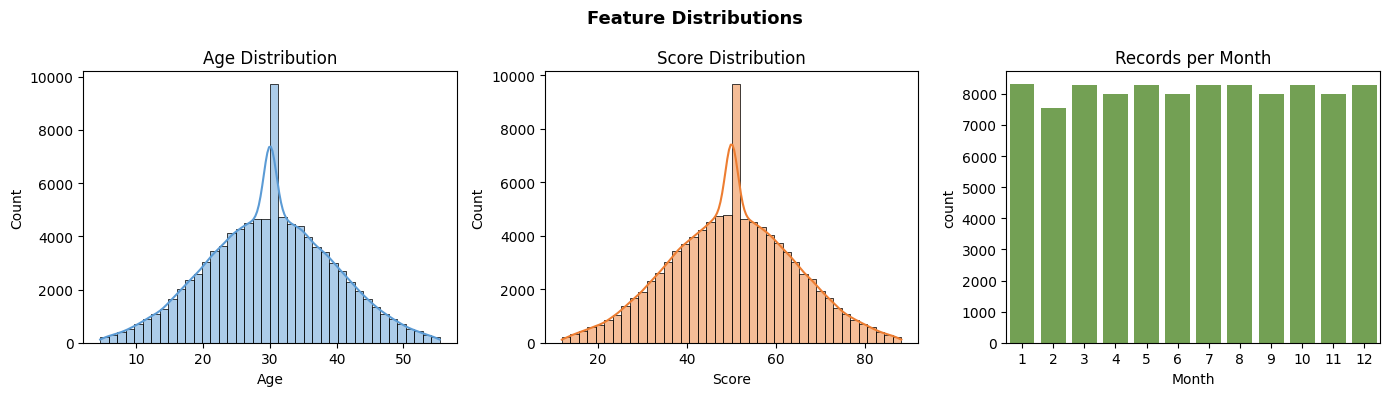

Saved feature_distributions.png


In [5]:
# Distribution plots
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.histplot(df_encoded['Age'], bins=40, color='#5B9BD5', kde=True, ax=axes[0])
axes[0].set_title('Age Distribution')

sns.histplot(df_encoded['Score'], bins=40, color='#ED7D31', kde=True, ax=axes[1])
axes[1].set_title('Score Distribution')

sns.countplot(x='Month', data=df_encoded, color='#70AD47', ax=axes[2])
axes[2].set_title('Records per Month')

plt.suptitle('Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved feature_distributions.png")

## Step 5: Export Model-Ready Dataset
Saving the fully encoded, model-ready feature matrix as model_ready_features.csv.
This file is ready to be ingested directly by any ML algorithm.

In [6]:
df_encoded.to_csv('model_ready_features.csv', index=False)
print("Saved model_ready_features.csv")
print("Final shape:", df_encoded.shape)
print("\nFinal columns:", df_encoded.columns.tolist())

Saved model_ready_features.csv
Final shape: (97564, 12)

Final columns: ['User_ID', 'Age', 'Score', 'Month', 'DayOfWeek', 'Is_Weekend', 'Dept_HR', 'Dept_Marketing', 'Dept_Sales', 'City_New York', 'City_Paris', 'City_Tokyo']
